# run on astro3

In [1]:
import sys, pdb, numpy as np, astropy
import pylab as pl
sys.path.append('../pysrc/')
from workdirs import *
from importlib import reload
from astropy import constants as cons, units as un

In [2]:
import FIRE_files as ff
import my_utils as u
ff.pyobjDir = basedir+'pyobj/profilers/'


Behroozi+18 not loaded


In [3]:
#f = np.load('/Users/jonathanstern/Dropbox/jonathanmain/CGM/rapidCoolingCGM/pyobj/no_yt_analysis/profiler_m12i_md_7100_z0.1377.npz')

In [4]:
simnames = ('m11d','m11h','m11i','m12b','m12f','m12i','m12r','m12w')
iSnapshot=600
Rimp2Rvirs = np.arange(0.1,1.01,0.02)
I_Ha = np.zeros((len(simnames),len(Rimp2Rvirs)))

In [ ]:
for isim,simname in enumerate(simnames):
    print('==========',simname,'============')
    _simdir = simdir + 'metal_diffusion/%s_r7100/'%simname
    sim = ff.Snapshot_meta(simname,'md','7100',_simdir+'output/',
                               '/jonathan_storage/sternjon/%s.dat'%simname,
                               iSnapshot=iSnapshot,snapshot_in_directory=(simname[2]=='2'))
    snapshot = ff.Snapshot(sim,loadAll=False)
    profiler = ff.Snapshot_profiler(snapshot)    
    print(profiler.rvir)
    HaEmission = profiler.profile1D('Halpha_emission','VW') #erg/cm^3/s
    profiler.tofile()
    #project
    for iRimp,Rimp in enumerate(Rimp2Rvirs*profiler.rvir):
        rs = profiler.rs_midbins()
        coeff = (1-(Rimp/rs)**2)
        new_coeff = np.where(coeff > 0, coeff ** -0.5, 0.0)
        drs = profiler.drs_midbins()
        ind = new_coeff.nonzero()[0][0]
        drs[ind] *= (rs[ind]-Rimp) / (rs[ind]-rs[ind-1])
        SB_emitted = np.nansum(HaEmission * drs *un.kpc.to('cm')*new_coeff) #erg/cm^2/s
        SB_observed = SB_emitted * (1+profiler.z)**-4
        I_Ha[isim,iRimp] = SB_observed
I_Ha *= 2.4e-11 / 4*np.pi #erg/cm^2/s/arcsec
#project

In [7]:
# run on local computer

In [10]:
I_Ha=np.array([[6.10342999e-19, 4.38357453e-19, 3.22445122e-19, 2.58398526e-19,
        2.02070471e-19, 1.67837160e-19, 1.35340330e-19, 1.03425157e-19,
        8.06117949e-20, 6.35744038e-20, 5.22481133e-20, 4.46104772e-20,
        4.07774271e-20, 3.42486086e-20, 2.97542357e-20, 2.56134303e-20,
        2.23979207e-20, 1.95364379e-20, 1.76521005e-20, 1.61037750e-20,
        1.42721409e-20, 1.30545471e-20, 1.29111377e-20, 1.26158446e-20,
        1.25036707e-20, 1.14218136e-20, 1.03539661e-20, 8.56716065e-21,
        7.73799218e-21, 7.22983612e-21, 6.72858022e-21, 6.75506352e-21,
        6.51997713e-21, 6.10553820e-21, 5.62922462e-21, 4.83661157e-21,
        3.89814057e-21, 3.14609205e-21, 2.27018861e-21, 1.50518018e-21,
        1.03824841e-21, 8.10130154e-22, 7.64794338e-22, 7.57351136e-22,
        6.61391586e-22, 4.79711900e-22],
       [4.54756588e-19, 3.21025525e-19, 2.46616890e-19, 1.83656913e-19,
        1.21643498e-19, 9.40438907e-20, 7.45396162e-20, 5.61937372e-20,
        3.85333003e-20, 3.04552226e-20, 2.29889952e-20, 1.83859291e-20,
        1.64697829e-20, 1.42169326e-20, 1.29199052e-20, 1.21848465e-20,
        1.16786753e-20, 1.09463360e-20, 9.34409033e-21, 8.40781203e-21,
        7.45393995e-21, 6.46968147e-21, 5.69001089e-21, 4.50771065e-21,
        3.96567195e-21, 3.62773123e-21, 3.53425584e-21, 3.36183680e-21,
        3.31341607e-21, 3.37703726e-21, 3.45588446e-21, 3.63813479e-21,
        3.90207252e-21, 4.17824173e-21, 3.60780086e-21, 2.40075687e-21,
        1.58070523e-21, 9.86499137e-22, 6.64105887e-22, 5.61241520e-22,
        4.87828173e-22, 3.95747363e-22, 3.49639574e-22, 3.34196492e-22,
        3.21731573e-22, 3.12894710e-22],
       [8.23028834e-19, 4.40964900e-19, 2.55303717e-19, 1.70476255e-19,
        1.23453242e-19, 1.00070543e-19, 7.65527281e-20, 5.61571980e-20,
        4.03122654e-20, 2.94558321e-20, 2.26675708e-20, 1.74636740e-20,
        1.47280302e-20, 1.05298436e-20, 8.29742978e-21, 6.80359167e-21,
        5.68965707e-21, 5.20123582e-21, 4.89120506e-21, 4.61049380e-21,
        4.30770002e-21, 4.43820214e-21, 3.20799315e-21, 1.51495753e-21,
        1.01089799e-21, 7.26420885e-22, 5.72501239e-22, 4.67613995e-22,
        4.10353340e-22, 3.70713839e-22, 3.49428911e-22, 3.50163661e-22,
        3.49851004e-22, 3.41804477e-22, 3.37418839e-22, 3.32899332e-22,
        3.29277764e-22, 3.25151546e-22, 3.20059340e-22, 3.10534823e-22,
        2.97114498e-22, 2.86045670e-22, 2.79356474e-22, 2.37114288e-22,
        1.71302481e-22, 1.33556469e-22],
       [5.65473983e-19, 3.39419857e-19, 2.11080094e-19, 1.46411530e-19,
        1.05846115e-19, 7.87366252e-20, 5.73704095e-20, 4.14322116e-20,
        3.13109531e-20, 2.44775940e-20, 1.90558112e-20, 1.52040653e-20,
        1.20847503e-20, 8.84621626e-21, 7.24364137e-21, 5.48271683e-21,
        4.81707391e-21, 4.42686154e-21, 3.72095020e-21, 3.02368045e-21,
        2.27372887e-21, 1.61413293e-21, 1.34061529e-21, 9.34584970e-22,
        5.50294700e-22, 3.72259127e-22, 3.39841428e-22, 3.09082189e-22,
        2.96758557e-22, 2.86779363e-22, 2.77604262e-22, 2.74834038e-22,
        2.72444929e-22, 2.68137240e-22, 2.63264091e-22, 2.60432893e-22,
        2.58068612e-22, 2.53507083e-22, 2.51057796e-22, 2.51716967e-22,
        2.52479700e-22, 2.53740528e-22, 2.55340323e-22, 2.57908021e-22,
        2.62133663e-22, 2.69197705e-22],
       [4.66637741e-19, 2.71242527e-19, 1.63100713e-19, 1.08675140e-19,
        6.24167477e-20, 4.67185481e-20, 3.65663939e-20, 2.86737882e-20,
        2.42673717e-20, 1.78898342e-20, 1.25391225e-20, 8.55186233e-21,
        6.52830403e-21, 4.24537508e-21, 3.41178508e-21, 2.96645662e-21,
        2.75399804e-21, 2.50176715e-21, 2.25825175e-21, 1.55206208e-21,
        1.00825477e-21, 7.84663385e-22, 6.97217858e-22, 5.93588000e-22,
        5.53239738e-22, 5.31939671e-22, 5.27552868e-22, 5.21592339e-22,
        4.99118389e-22, 4.00997832e-22, 3.63471492e-22, 3.53039958e-22,
        3.54835232e-22, 3.59257477e-22, 3.63873043e-22, 3.68166487e-22,
        3.73779628e-22, 3.81504629e-22, 3.90623912e-22, 4.01268818e-22,
        4.14406456e-22, 4.30178630e-22, 4.49273395e-22, 4.72878438e-22,
        5.02745277e-22, 5.42243560e-22],
       [2.09171618e-19, 9.53882067e-20, 6.04294753e-20, 4.24659540e-20,
        2.67575737e-20, 2.39469694e-20, 1.93186035e-20, 1.45795325e-20,
        1.10745851e-20, 9.78456168e-21, 8.72344498e-21, 8.48476214e-21,
        8.13314595e-21, 5.90713833e-21, 3.88163879e-21, 2.64451518e-21,
        1.67085186e-21, 1.07532305e-21, 8.27207402e-22, 6.67240024e-22,
        5.29745607e-22, 4.27678674e-22, 3.74575391e-22, 3.38922557e-22,
        3.21091323e-22, 3.02395130e-22, 2.93062749e-22, 2.84835893e-22,
        2.80631532e-22, 2.75493326e-22, 2.71618582e-22, 2.72595509e-22,
        2.74259531e-22, 2.76090383e-22, 2.78887734e-22, 2.85061783e-22,
        2.94971708e-22, 3.07886629e-22, 3.24724750e-22, 3.46200481e-22,
        3.75606470e-22, 4.13806312e-22, 4.70225204e-22, 5.35281153e-22,
        4.16514728e-22, 1.56867060e-22],
       [2.35237357e-19, 1.24118718e-19, 5.28277702e-20, 2.52602999e-20,
        1.81257628e-20, 1.63367538e-20, 1.16911657e-20, 8.70618184e-21,
        7.27993736e-21, 6.62522876e-21, 5.47255655e-21, 4.42112333e-21,
        4.01093584e-21, 3.33399334e-21, 3.35449845e-21, 3.16925853e-21,
        2.89112490e-21, 2.65656777e-21, 2.42616537e-21, 2.18378193e-21,
        2.02905548e-21, 1.90174392e-21, 1.67472865e-21, 1.30900805e-21,
        1.26865974e-21, 7.61824719e-22, 2.70311269e-22, 7.34682735e-23,
        5.16535612e-23, 4.37519948e-23, 3.73604716e-23, 3.47232008e-23,
        3.29200786e-23, 3.21455954e-23, 3.17735807e-23, 3.14000904e-23,
        2.99861817e-23, 2.82057633e-23, 2.68945437e-23, 2.60099041e-23,
        2.54245257e-23, 2.50358435e-23, 2.48739633e-23, 2.48191308e-23,
        2.48456700e-23, 2.49370023e-23],
       [1.26113417e-19, 4.98497429e-20, 2.37747690e-20, 1.46046375e-20,
        8.62580947e-21, 7.86206578e-21, 6.83399396e-21, 6.18549593e-21,
        5.63783529e-21, 5.05173203e-21, 4.92416919e-21, 3.93516907e-21,
        3.23144229e-21, 2.83111309e-21, 2.48139674e-21, 2.54713143e-21,
        2.73354142e-21, 2.34498263e-21, 1.38819911e-21, 7.77516275e-22,
        5.36960178e-22, 5.11836016e-22, 4.86322392e-22, 4.06826370e-22,
        3.65415554e-22, 3.53840087e-22, 3.54987104e-22, 3.46076671e-22,
        3.29019680e-22, 3.39018649e-22, 3.47613038e-22, 3.60287920e-22,
        3.76681132e-22, 3.98000531e-22, 4.24595245e-22, 4.63288615e-22,
        5.21938762e-22, 5.37742459e-22, 3.57553013e-22, 1.32433969e-22,
        6.63843972e-23, 5.64752450e-23, 5.30808427e-23, 5.45079498e-23,
        5.42190413e-23, 3.96286440e-23],
       [1.27862919e-19, 5.33889697e-20, 2.64242091e-20, 1.45192056e-20,
        9.01927880e-21, 6.72375407e-21, 3.66191909e-21, 2.50087491e-21,
        1.90927588e-21, 1.70522137e-21, 1.54516896e-21, 1.49938416e-21,
        1.49698613e-21, 1.37695081e-21, 1.35351103e-21, 1.42450660e-21,
        1.35161330e-21, 1.14948199e-21, 1.02602258e-21, 9.97431824e-22,
        1.00812950e-21, 1.00727623e-21, 1.03082510e-21, 9.85357875e-22,
        9.06559328e-22, 6.75042104e-22, 4.41919002e-22, 3.48271554e-22,
        3.59854437e-22, 3.30357529e-22, 2.62880138e-22, 2.69765591e-22,
        2.79585230e-22, 2.91540640e-22, 3.06409806e-22, 3.24943149e-22,
        3.48675211e-22, 3.80612698e-22, 4.26792253e-22, 4.94595166e-22,
        5.73746900e-22, 4.43268288e-22, 1.81704761e-22, 3.25810509e-23,
        1.35080730e-23, 1.32861654e-23],
       [7.19165185e-20, 3.34957682e-20, 1.43395740e-20, 7.76120389e-21,
        6.07967058e-21, 5.91160558e-21, 4.52550782e-21, 4.28639267e-21,
        3.82397380e-21, 2.76213956e-21, 2.11618557e-21, 1.97345953e-21,
        1.66612138e-21, 1.36435898e-21, 1.32109828e-21, 1.19426337e-21,
        1.07664246e-21, 1.02289233e-21, 9.40552610e-22, 8.25046171e-22,
        7.20804098e-22, 6.01683385e-22, 5.24282276e-22, 4.58219226e-22,
        4.41628461e-22, 4.36671113e-22, 4.37773248e-22, 4.42279452e-22,
        4.57433650e-22, 4.83481638e-22, 5.14728825e-22, 5.67568172e-22,
        6.31513402e-22, 5.83415988e-22, 3.84708117e-22, 2.92474408e-22,
        2.95090815e-22, 2.99245261e-22, 2.98770520e-22, 2.10832560e-22,
        9.64111324e-23, 5.56058888e-23, 5.02988324e-23, 4.96669066e-23,
        4.98993525e-23, 5.01933707e-23],
       [3.81278655e-20, 1.47666309e-20, 6.60808348e-21, 5.90866873e-21,
        4.02699253e-21, 3.65801318e-21, 2.38046597e-21, 1.71094751e-21,
        1.20081260e-21, 1.06644580e-21, 9.25112329e-22, 8.40230065e-22,
        7.82516550e-22, 6.89260701e-22, 6.73576621e-22, 6.59595555e-22,
        6.48725037e-22, 6.18933640e-22, 6.01888482e-22, 5.24930033e-22,
        4.92246930e-22, 4.55103688e-22, 4.49713431e-22, 4.61477669e-22,
        4.14411830e-22, 3.76389839e-22, 3.79859255e-22, 3.89114138e-22,
        4.15037043e-22, 4.50731197e-22, 4.67281539e-22, 3.31562970e-22,
        2.57827723e-22, 2.54596763e-22, 2.66336158e-22, 2.92053138e-22,
        3.19280765e-22, 3.11638820e-22, 1.92535733e-22, 8.52457379e-23,
        5.43901597e-23, 4.93104259e-23, 4.79558168e-23, 4.78360256e-23,
        4.83088823e-23, 4.88044103e-23]])

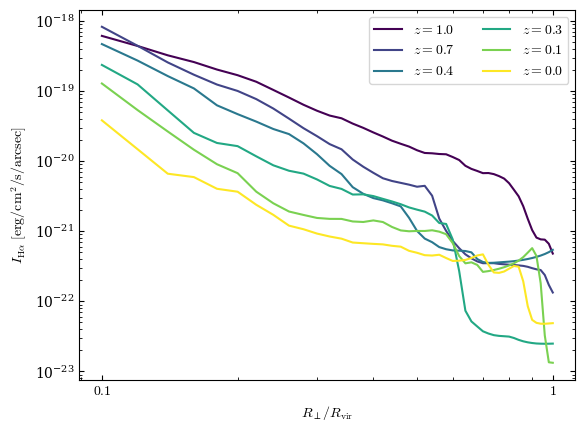

In [11]:
ax = pl.subplot(111)
for i in range(11):
    if i%2==1: continue
    pl.loglog(Rimp2Rvirs, I_Ha[i,:],
              c=pl.get_cmap('viridis')(i/10),
             label=r'$z=%.1f$'%ff.z_from_iSnapshot(iSnapshots[i]))
pl.legend(ncol=2)
pl.xlabel(r'$R_\perp / R_{\rm vir}$')
pl.ylabel(r'$I_{\rm H\alpha}\ [{\rm erg/cm^2/s/arcsec}]$')
ax.xaxis.set_major_formatter(u.arilogformatter)
pl.savefig('I_Ha.png')

SyntaxError: invalid syntax (Cloudy.py, line 1392)